# Lectura de datos: PracticasEolica.csv

## Grupo: 0

## Equipo:

- Ivan Legasa
- Matei Mendiburu
- Josue Isai Hernandez


In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Configuración para que los gráficos se vean bien
%matplotlib inline
plt.style.use('ggplot')

## Carga de datos

In [66]:
file_path = 'PracticasEolica.csv'

try:
    # Intentamos leer con utf-8
    df = pd.read_csv(file_path, sep=';')
except UnicodeDecodeError:
    # Si falla, intentamos con latin-1
    df = pd.read_csv(file_path, sep=';', encoding='latin-1')

# Convertir la columna de Fecha-hora a formato datetime
df['Fecha-hora'] = pd.to_datetime(df['Fecha-hora'], dayfirst=True)

df.head()

,Fecha-hora,Temperatura ºC,Humedad relativa %,Radiación global W/m²,Insolación s,Desviación velocidad 10 m m/s,Velocidad viento 10 m m/s,Dirección viento 10 m º,Desviación dirección viento 10 m º,Velocidad racha máxima 10 m m/s,Dirección racha máxima 10 m º,Precipitación l/m²,Presión atmosférica mbar
0,2025-01-01 00:00:00,3.03,35.48,NaN,NaN,0.46,5.10,156.1,3.06,6.37,159.4,0.0,911.0
1,2025-01-01 00:10:00,2.62,39.76,NaN,NaN,0.27,5.84,154.9,3.24,6.52,153.8,0.0,911.0
2,2025-01-01 00:20:00,2.35,43.06,NaN,NaN,0.43,6.39,154.4,4.08,7.74,157.9,0.0,910.0
3,2025-01-01 00:30:00,2.43,41.25,NaN,NaN,0.43,5.91,156.4,3.48,7.11,151.6,0.0,910.0
4,2025-01-01 00:40:00,2.55,38.66,NaN,NaN,0.58,5.16,151.0,5.34,6.42,153.3,0.0,910.0


## Información básica del dataset

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Fecha-hora                          52560 non-null  datetime64[us]
 1   Temperatura ºC                      52560 non-null  float64       
 2   Humedad relativa %                  52560 non-null  float64       
 3   Radiación global W/m²               46164 non-null  float64       
 4   Insolación s                        46164 non-null  float64       
 5   Desviación velocidad 10 m m/s       52411 non-null  float64       
 6   Velocidad viento 10 m m/s           52411 non-null  float64       
 7   Dirección viento 10 m º             41409 non-null  float64       
 8   Desviación dirección viento 10 m º  41411 non-null  float64       
 9   Velocidad racha máxima 10 m m/s     52411 non-null  float64       
 10  Dirección racha máxima 10 m º    

In [68]:
df.describe()

,Fecha-hora,Temperatura ºC,Humedad relativa %,Radiación global W/m²,Insolación s,Desviación velocidad 10 m m/s,Velocidad viento 10 m m/s,Dirección viento 10 m º,Desviación dirección viento 10 m º,Velocidad racha máxima 10 m m/s,Dirección racha máxima 10 m º,Precipitación l/m²,Presión atmosférica mbar
count,52560,52560.000000,52560.000000,46164.000000,46164.000000,52411.000000,52411.000000,41409.000000,41411.000000,52411.000000,41409.000000,52560.000000,52558.000000
mean,2025-07-02 11:55:00.410959,9.457548,78.662564,187.190947,182.408327,0.798320,7.330029,209.886303,12.162308,9.331980,198.647538,0.013992,899.909466
min,2025-01-01 00:00:00,-7.470000,6.710000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,778.700000
25%,2025-04-02 05:57:30,3.480000,62.160000,0.000000,0.000000,0.460000,4.000000,144.000000,5.550000,5.540000,137.500000,0.000000,897.000000
50%,2025-07-02 11:55:00,7.985000,85.800000,0.000000,0.000000,0.730000,6.870000,159.600000,8.490000,8.770000,162.700000,0.000000,901.000000
75%,2025-10-01 17:52:30,14.750000,99.500000,303.900000,556.000000,1.060000,10.310000,334.600000,15.010000,12.690000,327.600000,0.000000,904.000000
max,2025-12-31 23:50:00,34.080000,99.700000,1215.000000,600.000000,8.000000,21.800000,360.000000,101.000000,32.730000,360.000000,18.070000,913.000000
std,NaN,7.947355,22.362596,281.467874,262.855578,0.463082,4.161223,115.096453,11.546174,4.828419,116.714789,0.161038,5.464587


## Visualización de la Velocidad del Viento

Graficamos la velocidad del viento a 10m a lo largo del tiempo e incluimos una línea para la velocidad media.

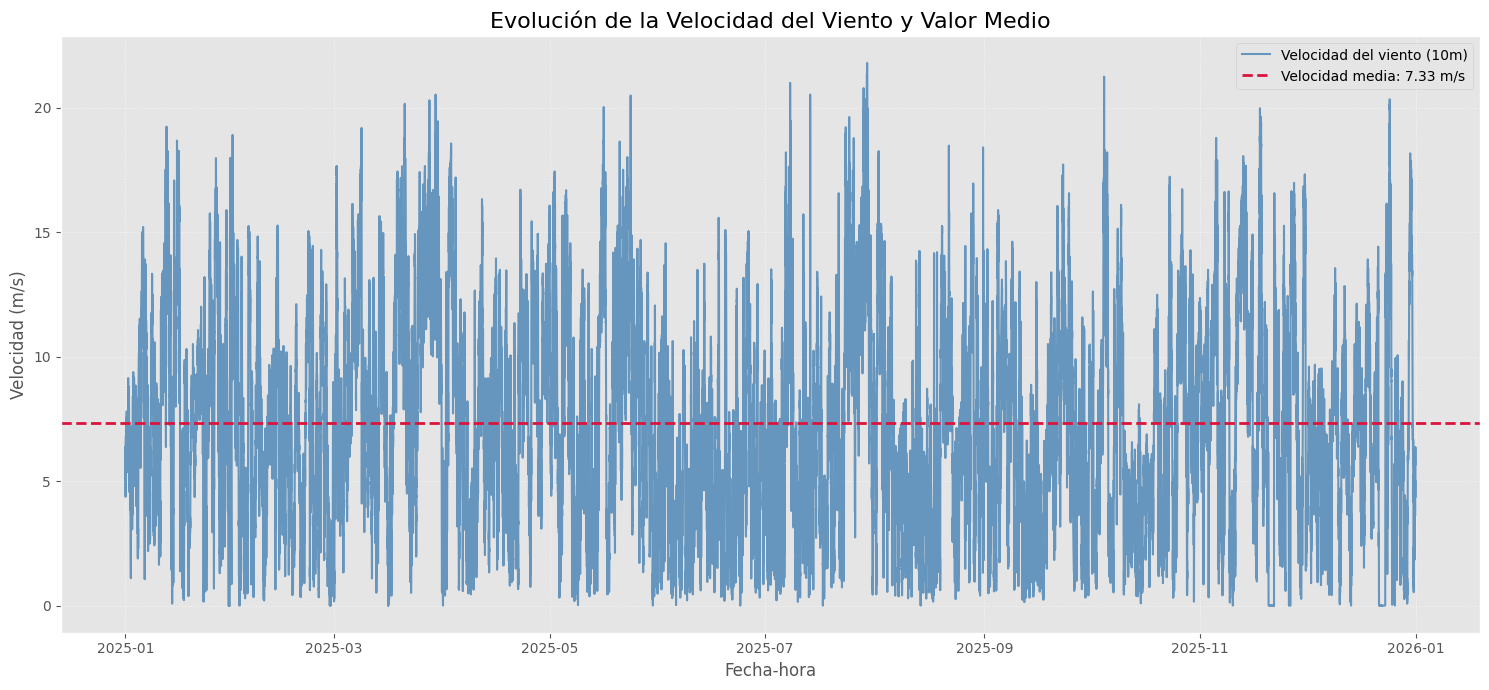

In [69]:
# Aseguramos que la columna sea numérica para poder calcular la media
import pandas as pd
df['Velocidad viento 10 m m/s'] = pd.to_numeric(df['Velocidad viento 10 m m/s'], errors='coerce')

# Cálculo de la velocidad media
velocidad_media = df['Velocidad viento 10 m m/s'].mean()

# Creación del gráfico
plt.figure(figsize=(15, 7))
plt.plot(df['Fecha-hora'], df['Velocidad viento 10 m m/s'], label='Velocidad del viento (10m)', color='steelblue', alpha=0.8)
plt.axhline(y=velocidad_media, color='crimson', linestyle='--', linewidth=2, label=f'Velocidad media: {velocidad_media:.2f} m/s')

# Estética del gráfico
plt.title('Evolución de la Velocidad del Viento y Valor Medio', fontsize=16)
plt.xlabel('Fecha-hora', fontsize=12)
plt.ylabel('Velocidad (m/s)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 1.3.2.2 Cálculo de la Densidad de Aire

In [70]:
R_d = 287.08 # J mol kg**-1 K**-1
df["T_Kelvin"] = df["Temperatura ºC"] + 273
df["P_Pascal"] = df["Presión atmosférica mbar"] * 100

df["rho"] = df["P_Pascal"] / (R_d * df["T_Kelvin"]) # kg m**-3

df.head()

,Fecha-hora,Temperatura ºC,Humedad relativa %,Radiación global W/m²,Insolación s,Desviación velocidad 10 m m/s,Velocidad viento 10 m m/s,Dirección viento 10 m º,Desviación dirección viento 10 m º,Velocidad racha máxima 10 m m/s,Dirección racha máxima 10 m º,Precipitación l/m²,Presión atmosférica mbar,T_Kelvin,P_Pascal,rho
0,2025-01-01 00:00:00,3.03,35.48,NaN,NaN,0.46,5.10,156.1,3.06,6.37,159.4,0.0,911.0,276.03,91100.0,1.149633
1,2025-01-01 00:10:00,2.62,39.76,NaN,NaN,0.27,5.84,154.9,3.24,6.52,153.8,0.0,911.0,275.62,91100.0,1.151343
2,2025-01-01 00:20:00,2.35,43.06,NaN,NaN,0.43,6.39,154.4,4.08,7.74,157.9,0.0,910.0,275.35,91000.0,1.151207
3,2025-01-01 00:30:00,2.43,41.25,NaN,NaN,0.43,5.91,156.4,3.48,7.11,151.6,0.0,910.0,275.43,91000.0,1.150872
4,2025-01-01 00:40:00,2.55,38.66,NaN,NaN,0.58,5.16,151.0,5.34,6.42,153.3,0.0,910.0,275.55,91000.0,1.150371


## 1.3.2.3 Presión a Nivel del Mar

In [71]:
import math

g = 9.81
z = 1353

df["H"] = R_d / g * df.T_Kelvin

df["P_0"] = df.apply(lambda row: row.P_Pascal / math.exp(-z / row.H), axis=1)

df.head()

,Fecha-hora,Temperatura ºC,Humedad relativa %,Radiación global W/m²,Insolación s,Desviación velocidad 10 m m/s,Velocidad viento 10 m m/s,Dirección viento 10 m º,Desviación dirección viento 10 m º,Velocidad racha máxima 10 m m/s,Dirección racha máxima 10 m º,Precipitación l/m²,Presión atmosférica mbar,T_Kelvin,P_Pascal,rho,H,P_0
0,2025-01-01 00:00:00,3.03,35.48,NaN,NaN,0.46,5.10,156.1,3.06,6.37,159.4,0.0,911.0,276.03,91100.0,1.149633,8077.746422,107711.355570
1,2025-01-01 00:10:00,2.62,39.76,NaN,NaN,0.27,5.84,154.9,3.24,6.52,153.8,0.0,911.0,275.62,91100.0,1.151343,8065.748175,107738.196423
2,2025-01-01 00:20:00,2.35,43.06,NaN,NaN,0.43,6.39,154.4,4.08,7.74,157.9,0.0,910.0,275.35,91000.0,1.151207,8057.846891,107637.636306
3,2025-01-01 00:30:00,2.43,41.25,NaN,NaN,0.43,5.91,156.4,3.48,7.11,151.6,0.0,910.0,275.43,91000.0,1.150872,8060.188012,107632.386889
4,2025-01-01 00:40:00,2.55,38.66,NaN,NaN,0.58,5.16,151.0,5.34,6.42,153.3,0.0,910.0,275.55,91000.0,1.150371,8063.699694,107624.518958


## 1.3.2.4 Tabla Resumen

In [72]:
cols = [
    "Mean Wind Speed (at 50m height)",
    "Mean Turbulence Intensity (at 10m/s)",
    "Max. 10min Average Wind Speed",
    "Maximum Gust",
    "Uncertainty of Wind Speed measurement",
    "Mean Wind Power and Total Wind Energy",
    "Autocorrelation coefficients",
    "Weibull Distribution constants",
    "shape factor (k)",
    "scale factor (C)",
    "Total number of valid data",
    "Included number of calms (<2m/s)",
    "Missing data",
    "Expected W.T. energy production",
    "W.T. Capacity Factor",
    "Calc. Mean Wind Speed at 64m height",
    "50% of the total WT energy can be produced in 33,7% of time",
    "WT Annual Energy Production & cap. factor",
    "calculated from data distribution",
    "calculated from Weibull distribution",
    "Best Sector in Energy contain NNE 31,70 %",
    "2nd best Sector in Energy contain N 27,66 %",
    "Best Sector in Time distribution NNE 24,80 %",
    "2nd best Sector in Time distribution N 22,24 %",
]

# 1.3.2.5 Año Medio

In [73]:
media_por_mes = df.groupby(df['Fecha-hora'].dt.month)['Velocidad viento 10 m m/s'].mean()
media_por_mes

Fecha-hora
1     8.249397
2     6.464358
3     9.816929
4     7.841176
5     7.948062
6     5.385655
7     7.649695
8     6.419803
9     6.724799
10    6.628275
11    8.347798
12    6.372896
Name: Velocidad viento 10 m m/s, dtype: float64

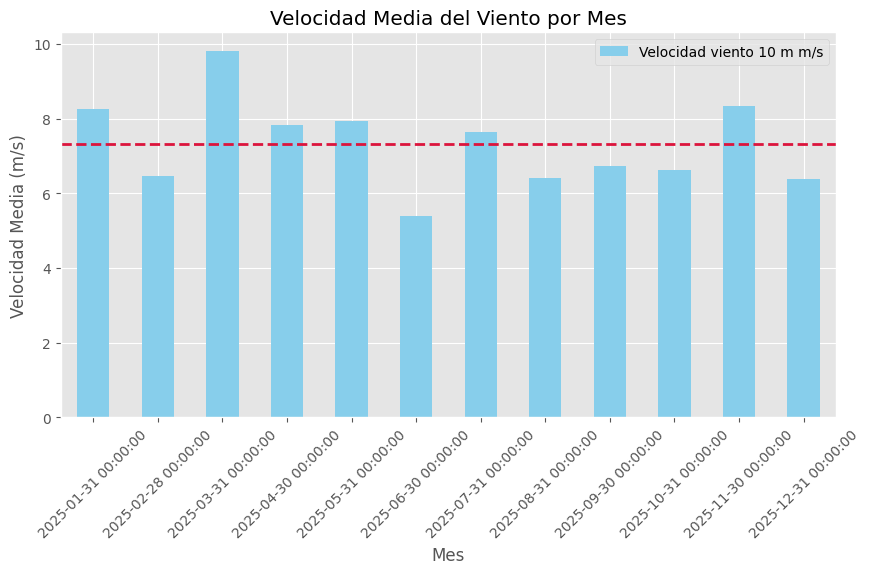

In [74]:
import matplotlib.pyplot as plt
# Calculamos la media
velocidad_mensual = df.set_index('Fecha-hora')['Velocidad viento 10 m m/s'].resample('ME').mean()
# Graficamos
plt.figure(figsize=(10, 5))
velocidad_mensual.plot(kind='bar', color='skyblue')
plt.title('Velocidad Media del Viento por Mes')
plt.xlabel('Mes')
plt.ylabel('Velocidad Media (m/s)')
plt.xticks(rotation=45)

plt.legend(loc='upper right')

plt.axhline(y=velocidad_media, color='crimson', linestyle='--', linewidth=2, label=f'Velocidad media: {velocidad_media:.2f} m/s')

plt.show()

## Conclusiones



In [75]:
df.to_csv('Grupo_0_P1.csv', index=False)

## 1.3.2.6 Rosa de los vientos

## 1.3.2.7 Día medio de cada mes